# Statistical Weather

Source of the data (Quelle: MeteoSchweiz; Source: MétéoSuisse; Fonte: MeteoSvizzera; Source: MeteoSwiss)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import os
from datetime import datetime

In [2]:
df_list = []
current_directory = os.getcwd()

folder_path = current_directory + "\\data\\dataTemp\\month"
csv_files = os.listdir(folder_path)

OUTPUT_CSV = "\\data\\dataWeather.csv"

for file in csv_files:
    try:
        df = pd.read_csv(folder_path + '\\' + file)
        df_list.append(df)
    except Exception as e:
        print(f"⚠️ Erreur de lecture {file} : {e}")

# Concaténation avec gestion des colonnes manquantes
if df_list:
    df_final = pd.concat(df_list, ignore_index=True, sort=False)
    df_final.to_csv(current_directory + OUTPUT_CSV, index=False)
    print(f"✅ Fichier final enregistré sous {OUTPUT_CSV}")  

✅ Fichier final enregistré sous \data\dataWeather.csv


Creation d'un dictionaire pour la corespondance des noms de colonne

In [56]:
columns_id = pd.read_csv('data/columns_identifier.csv', sep=';', encoding="latin1")

columns_id = pd.read_csv('data/columns_identifier.csv', sep=';', encoding="latin1")

columns_id["parameter_description_en"] = columns_id["parameter_description_en"].replace(to_replace=r';', value='/', regex=True)

dict_nameColumns = dict(zip(columns_id["parameter_shortname"], columns_id["parameter_description_en"]))

# Définir la colonne "nom" comme index
columns_id.set_index('parameter_shortname', inplace=True)

print(dict_nameColumns)
columns_id.head()

{'dkl010d0': 'Wind direction/ daily mean', 'dkl010h0': 'Wind direction/ hourly mean', 'dkl010z0': 'Wind direction/ ten minutes mean', 'erefaod0': 'Reference evaporation from FAO/ daily total', 'erefaoh0': 'Reference evaporation from FAO/ hourly total', 'erefaom0': 'Reference evaporation from FAO/ monthly total', 'erefaoy0': 'Reference evaporation from FAO/ annual total', 'fkl010d0': 'Wind speed scalar/ daily mean in m/s', 'fkl010d1': 'Gust peak (one second)/ daily maximum in m/s', 'fkl010d3': 'Gust peak (three seconds)/ daily maximum in m/s', 'fkl010h0': 'Wind speed scalar/ hourly mean in m/s', 'fkl010h1': 'Gust peak (one second)/ hourly maximum in m/s', 'fkl010h3': 'Gust peak (three seconds)/ hourly maximum in m/s', 'fkl010m0': 'Wind speed scalar/ monthly mean in m/s', 'fkl010m1': 'Gust peak (one second)/ monthly maximum in m/s', 'fkl010y0': 'Wind speed scalar/ annual mean in m/s', 'fkl010y1': 'Gust peak (one second)/ annual maximum in m/s', 'fkl010z0': 'Wind speed scalar/ ten minutes

,parameter_description_de,parameter_description_fr,parameter_description_it,parameter_description_en,parameter_group_de,parameter_group_fr,parameter_group_it,parameter_group_en,parameter_granularity,parameter_decimals,parameter_datatype,parameter_unit
parameter_shortname,,,,,,,,,,,,
dkl010d0,Windrichtung; Tagesmittel,Direction du vent; moyenne journalière,Direzione del vento; media giornaliera,Wind direction/ daily mean,Wind,vent,vento,wind,D,0,Integer,°
dkl010h0,Windrichtung; Stundenmittel,Direction du vent; moyenne horaire,Direzione del vento; media oraria,Wind direction/ hourly mean,Wind,vent,vento,wind,H,0,Integer,°
dkl010z0,Windrichtung; Zehnminutenmittel,Direction du vent; moyenne sur 10 minutes,Direzione del vento; media su 10',Wind direction/ ten minutes mean,Wind,vent,vento,wind,T,0,Integer,°
erefaod0,Referenzverdunstung nach FAO; Tagessumme,Évaporation de réference de FAO; somme journal...,Evaporazione referenze di FAO; somma giornaliera,Reference evaporation from FAO/ daily total,Verdunstung,évaporation,evaporazione,evaporation,D,1,Float,mm/d
erefaoh0,Referenzverdunstung nach FAO; Stundensumme,Évaporation de réference de FAO; somme horaire,Evaporazione referenze di FAO; somma oraria,Reference evaporation from FAO/ hourly total,Verdunstung,évaporation,evaporazione,evaporation,H,3,Float,mm/h


Creation d'un dictionnaire pour la corespondance des noms des lieux ou la mersure a été prise

In [42]:
nameContry = pd.read_csv('data/station_identifier.csv', sep=';', encoding="latin1")

nameContry["station_name"] = nameContry["station_name"].replace(to_replace=r';', value='/', regex=True)

dict_nameContry = dict(zip(nameContry["station_abbr"], nameContry["station_name"]))

print(dict_nameContry)
nameContry.head()

{'ABO': 'Adelboden', 'AEG': 'Oberägeri', 'AIG': 'Aigle', 'ALT': 'Altdorf', 'AND': 'Andeer', 'ANT': 'Andermatt', 'ARH': 'Altenrhein', 'ARO': 'Arosa', 'ATT': 'Les Attelas', 'BAN': 'Bantiger', 'BAS': 'Basel / Binningen', 'BEH': 'Passo del Bernina', 'BER': 'Bern / Zollikofen', 'BEZ': 'Beznau', 'BIA': 'Biasca', 'BIE': 'Bière', 'BIN': 'Binn', 'BIV': 'Bivio', 'BIZ': 'Bischofszell / Sitterdorf', 'BLA': 'Blatten, Lötschental', 'BOL': 'Boltigen', 'BOU': 'Bouveret', 'BRL': 'La Brévine', 'BRZ': 'Brienz', 'BUF': 'Buffalora', 'BUS': 'Buchs / Aarau', 'CDF': 'La Chaux-de-Fonds', 'CDM': 'Col des Mosses', 'CEV': 'Cevio', 'CGI': 'Nyon / Changins', 'CHA': 'Chasseral', 'CHB': 'Les Charbonnières', 'CHD': "Château-d'Oex", 'CHM': 'Chaumont', 'CHU': 'Chur', 'CHZ': 'Cham', 'CIM': 'Cimetta', 'CMA': 'Crap Masegn', 'COM': 'Acquarossa / Comprovasco', 'COV': 'Piz Corvatsch', 'COY': 'Courtelary', 'CRM': 'Cressier', 'DAV': 'Davos', 'DEM': 'Delémont', 'DIA': 'Les Diablerets', 'DIS': 'Disentis', 'DOL': 'La Dôle', 'EBK':

,station_abbr,station_name,station_canton,station_wigos_id,station_type_de,station_type_fr,station_type_it,station_type_en,station_dataowner,station_data_since,station_height_masl,station_height_barometer_masl,station_coordinates_lv95_east,station_coordinates_lv95_north,station_coordinates_wgs84_lat,station_coordinates_wgs84_lon,station_exposition_de,station_exposition_fr,station_exposition_it,station_exposition_en,station_url_de,station_url_fr,station_url_it,station_url_en
0,ABO,Adelboden,BE,0-20000-0-06735,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,"MeteoSchweiz, SLF",01.01.1901,1321.0,1326.0,2609372.0,1148939.0,46.491703,7.560703,Südosthang,Versant sud-est,Versante sud-orientale,south-eastern oriented slope,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
1,AEG,Oberägeri,ZG,0-20000-0-06676,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.02.1993,724.0,NaN,2688729.0,1220956.0,47.133636,8.608206,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
2,AIG,Aigle,VD,0-20000-0-06712,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1961,381.0,382.0,2560404.0,1130713.0,46.326647,6.924472,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
3,ALT,Altdorf,UR,0-20000-0-06672,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1864,438.0,440.0,2690181.0,1193564.0,46.887069,8.621894,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...
4,AND,Andeer,GR,0-20000-0-06787,Automatische Wetterstationen,Stations météorologiques automatiques,Stazioni meteorologiche automatiche,Automatic weather stations,MeteoSchweiz,01.01.1901,987.0,988.0,2752692.0,1164038.0,46.610139,9.431981,Ebene,Plaine,Pianura,plain,https://www.meteoschweiz.admin.ch/service-und-...,https://www.meteosuisse.admin.ch/services-et-p...,https://www.meteosvizzera.admin.ch/servizi-e-p...,https://www.meteoswiss.admin.ch/services-and-p...


Charge les données

In [21]:
data_frame = pd.read_csv('data/dataWeather.csv', sep=';')
pd.set_option("display.max_columns", 31)

data_frame.head()

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,prestad0,pp0qffd0,ppz850d0,ppz700d0,pp0qnhd0,...,rre150d0,rka150d0,htoautd0,gre000d0,oli000d0,olo000d0,osr000d0,ods000d0,sre000d0,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0
0,ABO,01.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABO,02.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABO,03.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABO,04.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABO,05.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


####   Column selectionnée                                                                               

 <div style="vertical-align: middle;">
    <p>station_abbr</p>
    <p>station_height_masl</p>
    <p>reference_timestamp</p>
    <p>Température de l'air à 5 cm de l'herbe / moyenne journalière [tre005d0]</p>
    <p>Humidité de l'air relative à 2 m du sol / moyenne journalière [ure200d0]</p>
    <p>Pression atmosphérique à l'altitude du baromètre (QFE) / moyenne journalière [prestad0]</p>
    <p>Rafale (intégration 3 s) / maximum journalier en m/s [fkl010d3]</p>
    <p>Foehn index / valeur journalière [wcc006d0]</p>
    <p>Précipitations / somme du jour 0 UTC - 0 UTC [rka150d0]</p>
    <p>Hauteur de neige (mesurée automatiquement) / mesure matinale de 6 UTC [htoautd0]/p>
    <p>Rayonnement global / moyenne journalière [gre000d0]</p>
    <p>Durée d'ensoleillement / somme journalière [sre000d0]</p>
    <p>Évaporation de réference de FAO / somme journalière [erefaod0]</p>
    <p>Jours de refroidissment (CDD) [xcd000d0]</p>
</div>  

In [22]:
columns_list = ['station_abbr','reference_timestamp','tre005d0',
                'ure200d0','prestad0','fkl010d3','wcc006d0','rka150d0',
                'htoautd0','gre000d0','sre000d0','erefaod0','xcd000d0']

complete_list = list(columns_id['parameter_shortname'])

column_names = data_frame.columns.tolist()

dif_list = list(set(column_names) ^ set(columns_list))

data_frame = data_frame.drop(columns=dif_list, axis=1)

data_frame.head()


,station_abbr,reference_timestamp,tre005d0,ure200d0,prestad0,fkl010d3,wcc006d0,rka150d0,htoautd0,gre000d0,sre000d0,erefaod0,xcd000d0
0,ABO,01.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABO,02.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABO,03.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABO,04.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABO,05.01.1901 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Modifie nom des villes

In [74]:
data_frame['station_abbr'] = data_frame['station_abbr'].map(dict_nameContry)

data_frame.head()


,station_abbr,reference_timestamp,tre005d0,ure200d0,prestad0,fkl010d3,wcc006d0,rka150d0,htoautd0,gre000d0,sre000d0,erefaod0,xcd000d0
0,NaN,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1901-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1901-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1901-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1901-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Change le format de la date

In [ ]:
data_frame['reference_timestamp'] = pd.to_datetime(data_frame['reference_timestamp'], format='%d.%m.%Y %H:%M')
data_frame.head()

Supprime les lignes en dessous de 1960

In [ ]:


# Suppression des lignes où l'année est inférieure au seuil
data_frame_1960 = data_frame[data_frame['reference_timestamp'].dt.year >= 1960]

data_frame_1960.head()

,station_abbr,reference_timestamp,tre005d0,ure200d0,prestad0,fkl010d3,wcc006d0,rka150d0,htoautd0,gre000d0,sre000d0,erefaod0,xcd000d0
21458,Adelboden,1960-01-01,NaN,54.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21459,Adelboden,1960-01-02,NaN,88.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21460,Adelboden,1960-01-03,NaN,91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21461,Adelboden,1960-01-04,NaN,79.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21462,Adelboden,1960-01-05,NaN,50.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Relative air humidity 2 m above ground

In [102]:
df_grouped_1960 = data_frame_1960.groupby(data_frame_1960['reference_timestamp'].dt.year)['ure200d0'].mean().reset_index()

df_grouped_1960.columns = ['year', 'mean']

df_grouped_1960.head()

,year,mean
0,1960,76.235897
1,1961,74.439906
2,1962,72.444494
3,1963,75.066109
4,1964,74.781628


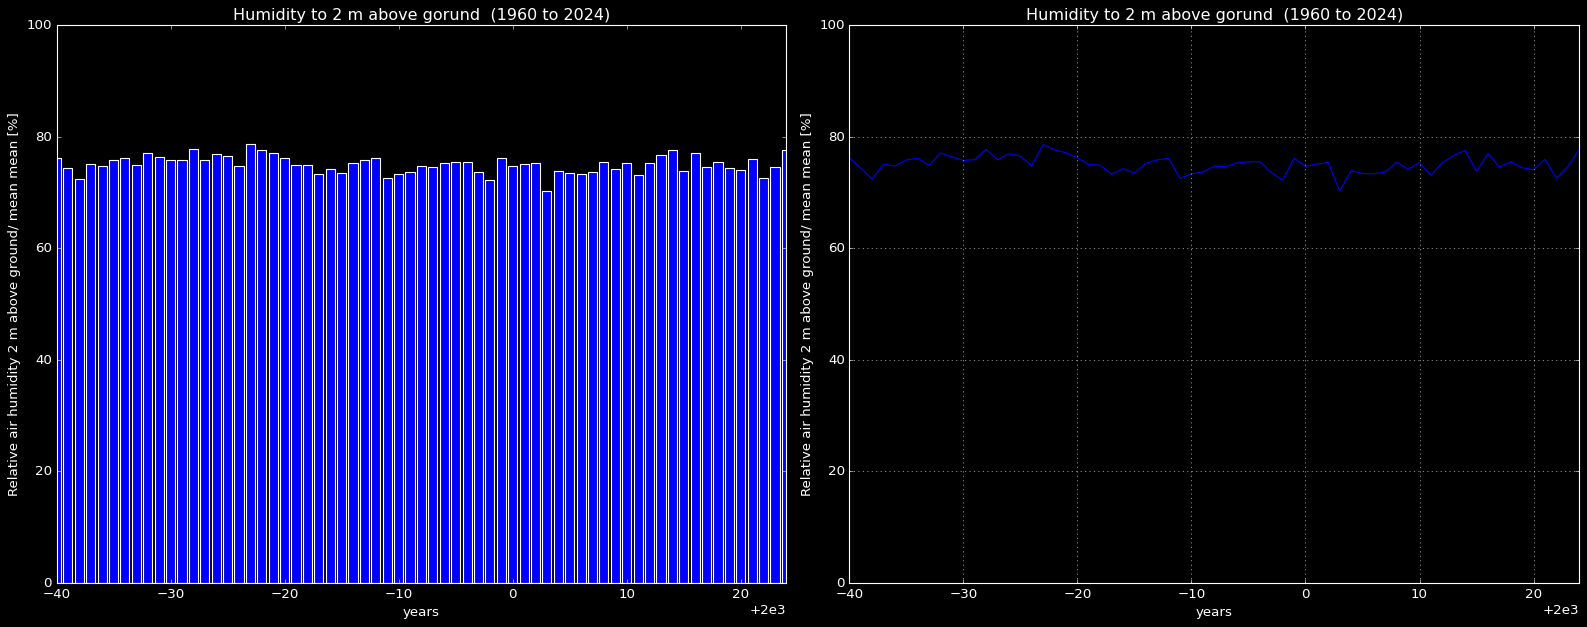

In [117]:
ligne_ure200d0 = columns_id.loc['ure200d0']  # Retourne les infos de Bob

unit_ure200d0 = ligne_ure200d0['parameter_unit']

X_ure200d0 = df_grouped_1960['year']
Y_ure200d0 = df_grouped_1960['mean']

#char graph
plt.style.use("dark_background")

# Création de deux graphiques horizontaux
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 1 ligne, 2 colonnes

plt.xlim(1960, 2024)  # Limite de l'axe X entre 0 et 10
plt.ylim(0, 100)  # Limite de l'axe Y entre 0 et 100


# Premier graphique
axes[0].bar(X_ure200d0, Y_ure200d0, color='blue')
axes[0].set_title("Humidity to 2 m above gorund  (1960 to 2024)")
axes[0].set_xlabel("years")
axes[0].set_ylabel(dict_nameColumns['ure200d0'].replace('daily', 'mean') + ' [' +  unit_ure200d0 + ']')
axes[0].set_xlim(1960, 2024)  # Limite de l'axe X entre 0 et 10
axes[0].set_ylim(0, 100)  # Limite de l'axe Y entre 0 et 100

# Deuxième graphique
axes[1].plot(X_ure200d0, Y_ure200d0, color='blue')
axes[1].set_title("Humidity to 2 m above gorund  (1960 to 2024)")
axes[1].set_xlabel("years")
axes[1].set_ylabel(dict_nameColumns['ure200d0'].replace('daily', 'mean') + ' [' +  unit_ure200d0 + ']')
axes[1].set_xlim(1960, 2024)  # Limite de l'axe X entre 0 et 10
axes[1].set_ylim(0, 100)  # Limite de l'axe Y entre 0 et 100
axes[1].grid(True)

# Ajustement de l'affichage
plt.tight_layout()
plt.show()


Supprime les lignes en dessous de 1970

In [110]:
# Suppression des lignes où l'année est inférieure au seuil
data_frame_1970 = data_frame[data_frame['reference_timestamp'].dt.year >= 1970]

data_frame_1970.head()

,station_abbr,reference_timestamp,tre005d0,ure200d0,prestad0,fkl010d3,wcc006d0,rka150d0,htoautd0,gre000d0,sre000d0,erefaod0,xcd000d0
25111,NaN,1970-01-01,NaN,79.3,NaN,NaN,NaN,NaN,NaN,NaN,318.0,NaN,NaN
25112,NaN,1970-01-02,NaN,88.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25113,NaN,1970-01-03,NaN,53.7,NaN,NaN,NaN,NaN,NaN,NaN,282.0,NaN,NaN
25114,NaN,1970-01-04,NaN,68.0,NaN,NaN,NaN,NaN,NaN,NaN,222.0,NaN,NaN
25115,NaN,1970-01-05,NaN,80.7,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


Sunshine duration/ daily total

In [111]:
df_grouped_1970 = data_frame_1970.groupby(data_frame_1970['reference_timestamp'].dt.year)['sre000d0'].mean().reset_index()

df_grouped_1970.columns = ['year', 'mean']

df_grouped_1970.head()

,year,mean
0,1970,260.327856
1,1971,311.424450
2,1972,255.955829
3,1973,276.332766
4,1974,254.589436


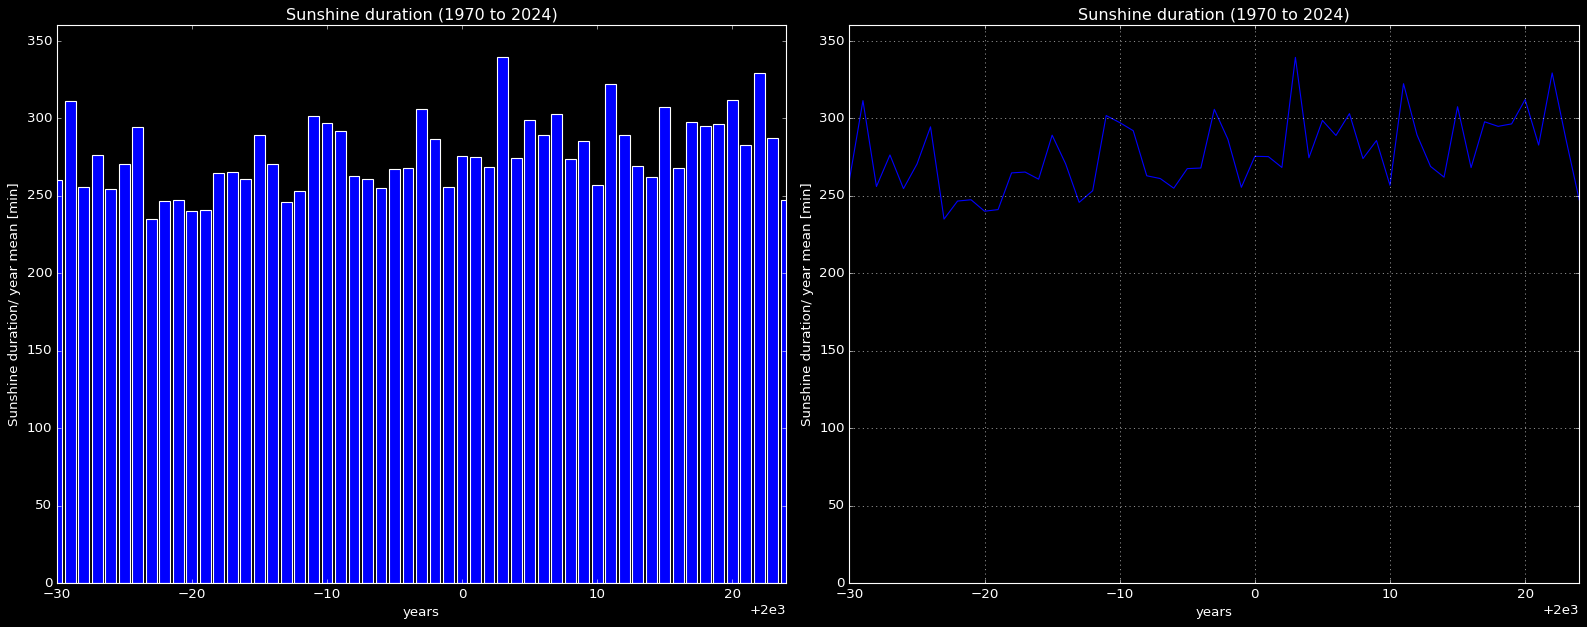

In [118]:
ligne_sre000d0= columns_id.loc['sre000d0']

unit_sre000d0 = ligne_sre000d0['parameter_unit']

X_sre000d0 = df_grouped_1970['year']
Y_sre000d0 = df_grouped_1970['mean']

#char graph
plt.style.use("dark_background")

# Création de deux graphiques horizontaux
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 1 ligne, 2 colonnes




# Premier graphique
axes[0].bar(X_sre000d0, Y_sre000d0, color='blue')
axes[0].set_title("Sunshine duration (1970 to 2024)")
axes[0].set_xlabel("years")
axes[0].set_ylabel(dict_nameColumns['sre000d0'].replace('daily total', 'year mean') + ' [' +  unit_sre000d0 + ']')
axes[0].set_xlim(1970, 2024)  # Limite de l'axe X entre 0 et 10
axes[0].set_ylim(0, 360)  # Limite de l'axe Y entre 0 et 100

# Deuxième graphique
axes[1].plot(X_sre000d0, Y_sre000d0, color='blue')
axes[1].set_title("Sunshine duration (1970 to 2024)")
axes[1].set_xlabel("years")
axes[1].set_ylabel(dict_nameColumns['sre000d0'].replace('daily total', 'year mean') + ' [' +  unit_sre000d0 + ']')
axes[1].set_xlim(1970, 2024)  # Limite de l'axe X entre 0 et 10
axes[1].set_ylim(0, 360)  # Limite de l'axe Y entre 0 et 100
axes[1].grid(True)

# Ajustement de l'affichage
plt.tight_layout()
plt.show()
       